<div class="alert alert-success">
    <h1>Assignment 1: Linear Regression</h1>
    <h3 align='center'>Machine Learning Course (4032-01)</h3>
    <h5 align='center'>Instructor: Dr.Mehran Safayani</h5>
    <h5 align='center'>TA: Arash Azhand</h5>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Create Dataset**

In [2]:
# Set random seed for reproducibility
np.random.seed(84)

# Generate 1000 random square feet values (ranging from 500 to 5000)
square_feet = np.random.randint(500, 5000, 1000)

# Define a linear relationship: Price = 150 * Square Feet + Noise
price = 150 * square_feet + np.random.normal(0, 50000, 1000)  # Adding some noise

# Create DataFrame
df = pd.DataFrame({'Square_Feet': square_feet, 'Price': price})

# Display first 5 rows
# your code here
print(df.head(5))

# Save to CSV and `index=False` with `to_csv` function
# your code here
df.to_csv('data.csv',index=False)
# if index becomes False, the row number of data will not be saved

   Square_Feet          Price
0         4325  741452.386180
1         3884  579469.230020
2         3952  645343.443296
3         4802  739800.223797
4         3681  541393.310522


# **Pandas**

## 1. Loading and displaying data

In [3]:
# Load dataset
# your code here
new_df=pd.read_csv('./data.csv')

# Display first few rows
# your code here
print(new_df.head(3))
print()
# Display basic info about the dataset (info())
# your code here
print(new_df.info())
print()
# Show basic statistics (describe())
# your code here
print(new_df.describe())

   Square_Feet          Price
0         4325  741452.386180
1         3884  579469.230020
2         3952  645343.443296

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Square_Feet  1000 non-null   int64  
 1   Price        1000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB
None

       Square_Feet          Price
count    1000.0000    1000.000000
mean     2779.3720  417609.739384
std      1328.1005  208568.294179
min       503.0000   -2844.368508
25%      1577.7500  231864.422582
50%      2803.5000  423585.806406
75%      3949.7500  592750.049374
max      4999.0000  863030.536808


## 2. Checking for missing values

Since we generated the dataset ourselves, it shouldn't have missing values. But in real-world datasets, handling missing values is crucial.

In [4]:
# your code here  # Count missing values in each column
print(new_df.isna().sum())

Square_Feet    0
Price          0
dtype: int64


## 3. Sorting and filtering data

Sort the dataset by price

In [5]:
# your code here
df_sorted=df.sort_values(by='Price',ascending=False)
print(df_sorted.head())  # Displays most expensive houses


     Square_Feet          Price
893         4989  863030.536808
141         4889  851242.048474
113         4993  837494.833195
205         4775  821429.585100
844         4967  820545.160785


Filter houses with square footage greater than 3000

In [6]:
# your code here
large_houses=new_df[new_df['Square_Feet']>3000]
large_houses.head()

,Square_Feet,Price
0,4325,741452.386180
1,3884,579469.230020
2,3952,645343.443296
3,4802,739800.223797
4,3681,541393.310522


## 4. Using `.iloc` for Indexing in Pandas

In [7]:
# Select rows from index 10 to 20 and both columns
# your code here
print(new_df.iloc[10:21,0:2])

    Square_Feet          Price
10         4578  724545.082445
11         1233  256045.664831
12          804  142136.369360
13          802  162714.078764
14         3896  592716.198017
15         4024  694229.377073
16         2856  414713.245096
17         4486  668811.369969
18         3958  636999.792545
19         1099  194851.444566
20         1196  204727.348302


## 5. Plotting with Pandas

Visualize the data using `df.plot` and `kind="scatter"`

<Axes: xlabel='Square_Feet', ylabel='Price'>

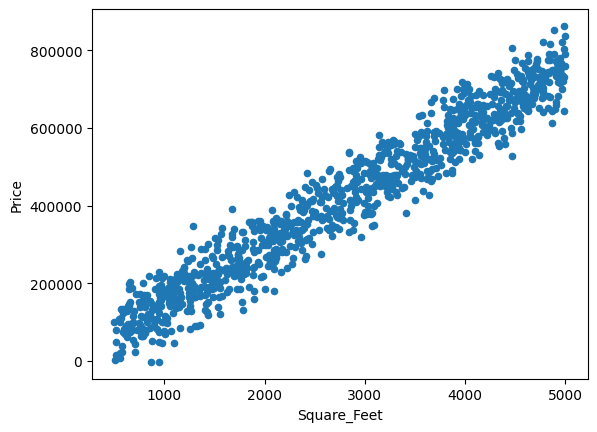

In [8]:
# your code here
new_df.plot(x='Square_Feet',y='Price',kind='scatter')

# **Numpy**

## 1. Creating NumPy Arrays


convert Pandas DataFrame columns into NumPy arrays and perform operations.

In [9]:
# Convert pandas columns to NumPy arrays
square_feet_np = new_df['Square_Feet'].to_numpy()
price_np = new_df['Price'].to_numpy()

# Display first 5 values
print(square_feet_np[:5])
print(price_np[:5])

[4325 3884 3952 4802 3681]
[741452.38617975 579469.23001986 645343.4432958  739800.22379669
 541393.31052222]


## 2. Basic Mathematical Operations

Perform element-wise operations on NumPy arrays.

In [10]:
# Multiply all square feet values by 2
double_sq_feet = square_feet_np*2
print(double_sq_feet[:5])

# Add a constant to price
price_plus_1000 = price_np+1000
print(price_plus_1000[:5])




[8650 7768 7904 9604 7362]
[742452.38617975 580469.23001986 646343.4432958  740800.22379669
 542393.31052222]


## 3. Reshaping and Indexing

Reshape *'square_feet_np'* and *'price_np'* to `(1000, 1)`

In [11]:
# Reshape arrays (not necessary for 1D, but useful for ML models)
square_feet_np = square_feet_np.reshape(1000,1)
price_np = price_np.reshape(1000,1)

# Accessing specific elements
print(square_feet_np[:5])  # First 5 house's square feet
print(price_np[-6:-1])  # Last 5 house's price

# Display the shape of each one
print(square_feet_np.shape)
print(price_np.shape)

[[4325]
 [3884]
 [3952]
 [4802]
 [3681]]
[[127902.32155049]
 [507599.43742675]
 [461888.25010112]
 [768263.04224501]
 [151040.59929105]]
(1000, 1)
(1000, 1)


## 4. Applying Functions

You should be able to use `np.mean` and `np.std`

In [12]:
# Calculate mean and standard deviation
square_feet_mean=np.mean(square_feet_np)
square_feet_std=np.std(square_feet_np)

# Normalize the square feet feature (Z-score normalization)
square_feet_norm = (square_feet_np - square_feet_mean) / square_feet_std
print(square_feet_norm[:5])  # Display first 5 normalized values


[[1.16437076]
 [0.83215143]
 [0.88337799]
 [1.52371005]
 [0.67922507]]


# **Matplotlib**

## 1. Scatter Plot (Better for Regression Visualization)

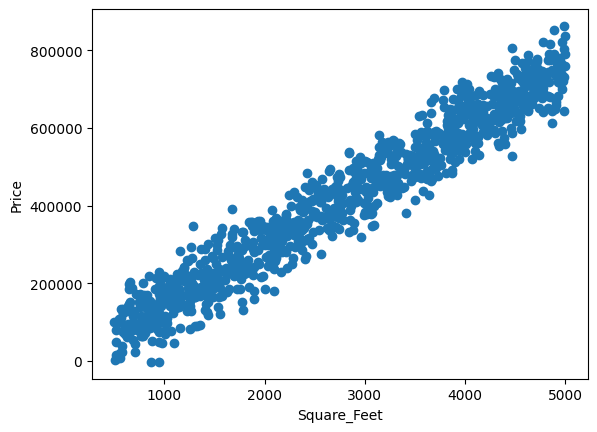

In [13]:
# your code here
plt.scatter(new_df['Square_Feet'],new_df['Price'])
plt.xlabel('Square_Feet')
plt.ylabel('Price')
#plt.legend()
plt.show()

## 2. Histogram

Let’s see how square footage is distributed.

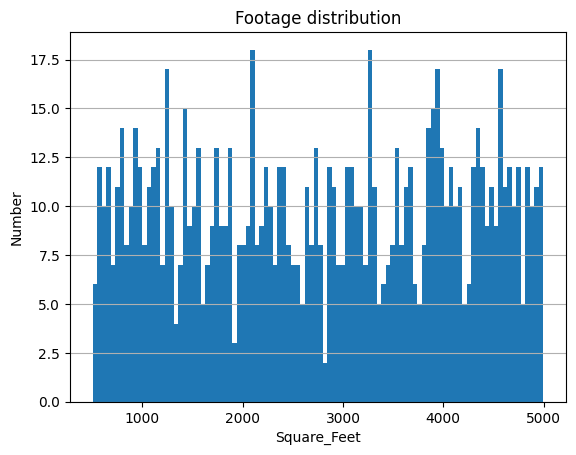

In [14]:
# your code here
plt.hist(new_df['Square_Feet'],bins=100)
plt.xlabel('Square_Feet')
plt.ylabel('Number')
plt.title('Footage distribution')
plt.grid(axis='y')
plt.show()

## 3. Customizing Plots (Labels, Grid, Legends, Colors, and Styles)

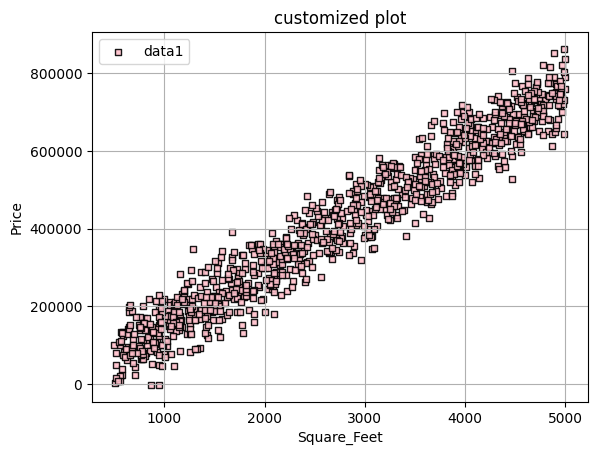

In [15]:
# your code here
plt.scatter(new_df['Square_Feet'],new_df['Price'],s=20,c='pink',alpha=0.9,edgecolor='black',marker='s',label='data1')
plt.xlabel('Square_Feet')
plt.ylabel('Price')
plt.title('customized plot')
plt.grid()
plt.legend()
plt.show()

## 4. Subplot

Use subplot and plot 1, 2 together

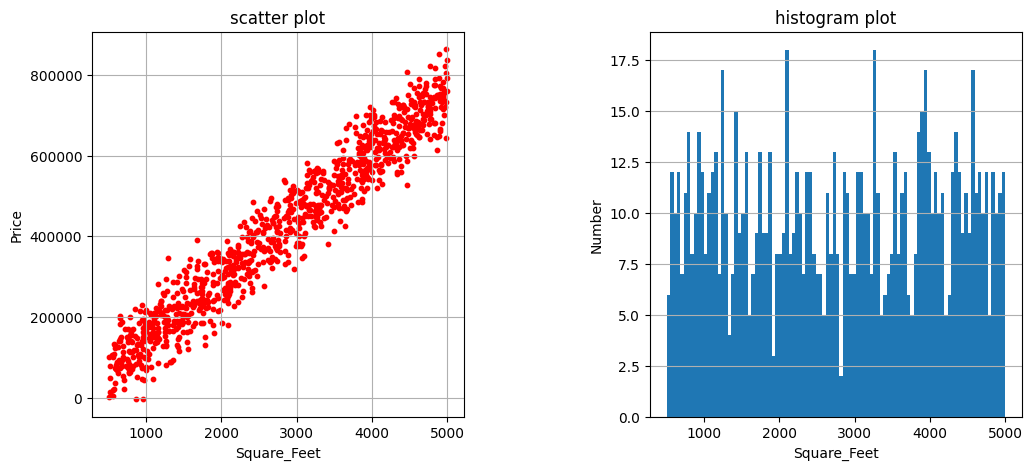

In [16]:
## your code here
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))

ax1.scatter(new_df['Square_Feet'],new_df['Price'],s=10,c='red')
ax1.set_title('scatter plot')
ax1.grid()
ax1.set_xlabel('Square_Feet')
ax1.set_ylabel('Price')


ax2.hist(new_df['Square_Feet'],bins=100)
ax2.set_title('histogram plot')
ax2.grid(axis='y')
ax2.set_xlabel('Square_Feet')
ax2.set_ylabel('Number')

plt.subplots_adjust(wspace=0.5)
plt.show()

# **Applying Linear Regression with Scikit-Learn**

## 1. Splitting the Dataset into Training and Test Sets

split 80% of the data for training and 20% for testing.

In [17]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
# your code here
X=df['Square_Feet']
y=df['Price']
# Split into train and test sets (80% train, 20% test)
# your code here
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
# Display dataset sizes
# your code here
print('x_train shape: ',x_train.shape)
print('y_train shape: ',y_train.shape)

print('x_test: ',x_test.shape)
print('y_test: ',y_test.shape)


x_train shape:  (800,)
y_train shape:  (800,)
x_test:  (200,)
y_test:  (200,)


## 2. Standardizing the Features

Since house sizes have large values, we normalize them for better model performance.

In [18]:
from sklearn.preprocessing import StandardScaler

# your code here
x_train=x_train.to_numpy().reshape(800,1)
y_train=y_train.to_numpy().reshape(800,1)
x_test=x_test.to_numpy().reshape(200,1)
y_test=y_test.to_numpy().reshape(200,1)


scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

## 3. Training the Linear Regression Model

In [20]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
# your code here
model=LinearRegression()
model.fit(x_train,y_train)
# Display model coefficients and Intercept
# your code here
print('Coefficients: ',model.coef_)
print('Intercept: ',model.intercept_)

Coefficients:  [[198388.72924561]]
Intercept:  [423361.44829895]


## 4. Making Predictions

In [23]:
# Predict on the test set
# your code here
y_pred=model.predict(x_test)
# Display first 5 predictions
print(y_pred[:5])


[[492820.37977279]
 [734988.31562173]
 [157393.32721435]
 [720464.35482271]
 [654418.55413663]]


## 5. Evaluating the Model

In [25]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Compute evaluation metrics
# your code here
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.4f}")  # Closer to 1 is better


Mean Squared Error (MSE): 3109507778.95
Mean Absolute Error (MAE): 44489.36
R² Score: 0.9366


## 6. Visualizing the Regression Line

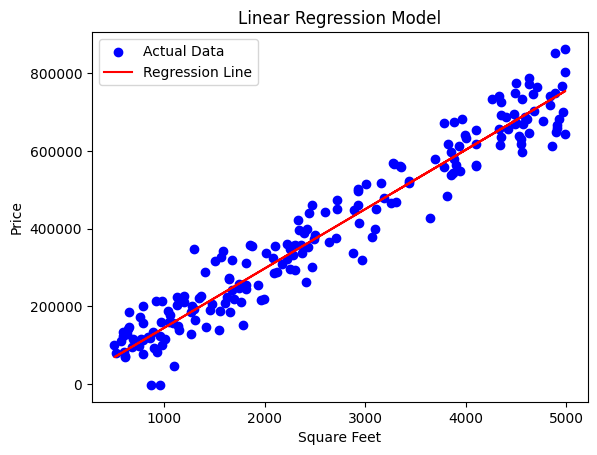

In [ ]:
# your code here
x_test=scaler.inverse_transform(x_test)
plt.scatter(x_test,y_test,label='Actual Data',c='blue')
plt.plot(x_test,y_pred,label='Regression Line',c='red')
plt.title('Linear Regression Model')
plt.xlabel('Square Feet')
plt.ylabel('Price')
plt.legend()
plt.show()

**expected output:**

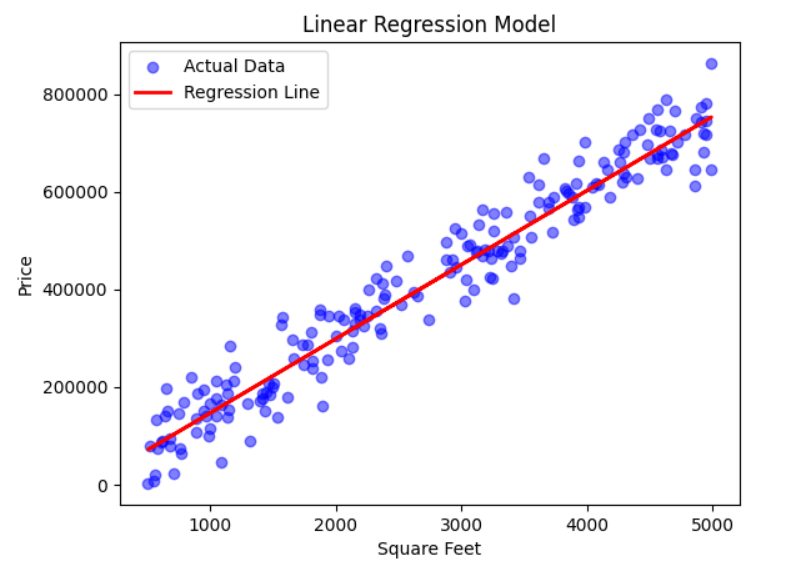